# Hotdog / Not Hotdog — Project 1
**Introduction to Deep Learning in Computer Vision (02516)**

Run the cells from top to bottom. All code is here; `hotdog.py` is no longer needed.
Training logs, tables, images and plots appear below and are retained when you save
this notebook. No result files, model checkpoints or figures are written to disk.

Models and training histories live in memory while the kernel is running. After a
restart, the saved outputs remain visible, but training must be rerun to use the models.
Choose models using validation accuracy; evaluate the winner on the test set at the end.

**Existing outputs are preserved from the previous implementation.** They have not
been recomputed with this simplified code; running a cell replaces its old outputs.

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms as T

%matplotlib inline

DATA_DIR = Path("dtu/datasets1/02516/hotdog_nothotdog")  # change if needed
SIZE, BATCH_SIZE, SEED = 128, 64, 0
EPOCHS, RESNET_EPOCHS = 12, 6
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
runs = {}  # models, metrics and histories stay in memory
print("training on:", device)

training on: cpu


## 1. Data
Resize to 128 × 128 and use ImageNet normalisation for both the CNN and ResNet.
Reserve 20% of the training folder for validation, using the same split in every run.
Augmentation adds a horizontal flip, a random crop and colour jitter to training only.

In [3]:
transform = T.Compose([
    T.Resize((SIZE, SIZE)), T.ToTensor(), T.Normalize(MEAN, STD),
])
aug_transform = T.Compose([
    T.Resize((SIZE, SIZE)), T.RandomHorizontalFlip(),
    T.RandomResizedCrop(SIZE, scale=(0.7, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
train_data = datasets.ImageFolder(DATA_DIR / "train", transform=transform)
aug_data = datasets.ImageFolder(DATA_DIR / "train", transform=aug_transform)
test_data = datasets.ImageFolder(DATA_DIR / "test", transform=transform)
assert train_data.class_to_idx == test_data.class_to_idx
CLASS_NAMES = train_data.classes

order = torch.randperm(len(train_data), generator=torch.Generator().manual_seed(SEED))
n_val = int(0.2 * len(order))
val_idx, train_idx = order[:n_val].tolist(), order[n_val:].tolist()
train_loader = DataLoader(Subset(train_data, train_idx), batch_size=BATCH_SIZE,
                          shuffle=True, generator=torch.Generator().manual_seed(SEED))
aug_train_loader = DataLoader(Subset(aug_data, train_idx), batch_size=BATCH_SIZE,
                              shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(Subset(train_data, val_idx), batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
print(f"train: {len(train_idx)} | validation: {len(val_idx)} | test: {len(test_data)}")
print("classes:", CLASS_NAMES)

train: 1638 | validation: 409 | test: 1862
classes: ['hotdog', 'nothotdog']


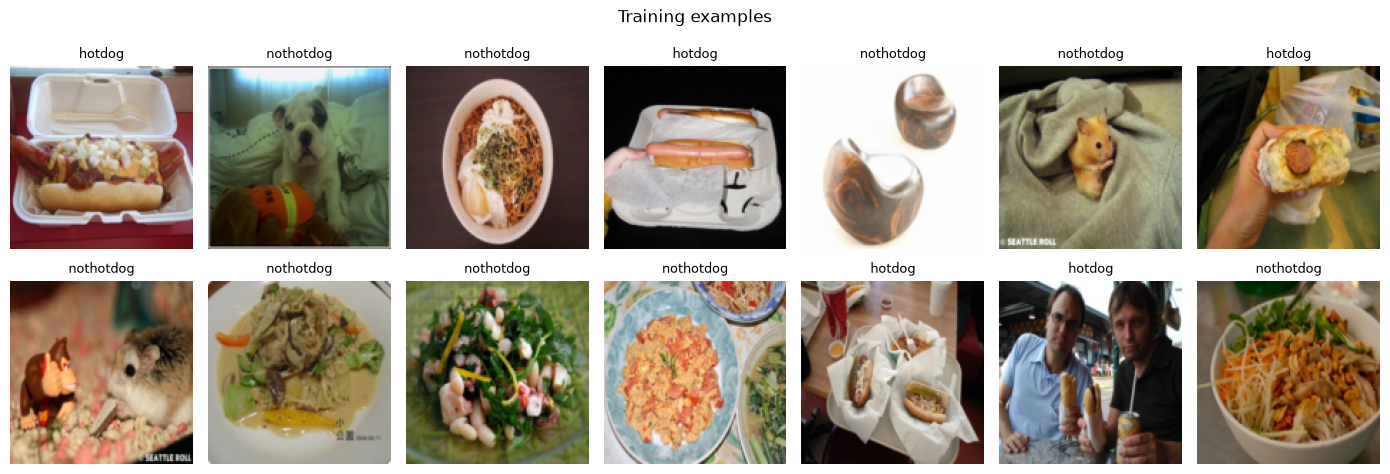

In [4]:
def denormalize(image):
    mean, std = torch.tensor(MEAN)[:, None, None], torch.tensor(STD)[:, None, None]
    return (image.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)


def show_images(images, titles, title=""):
    fig, axes = plt.subplots((len(images) + 6) // 7, 7, figsize=(14, 5), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        if i < len(images):
            ax.imshow(denormalize(images[i]))
            ax.set_title(titles[i], fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


images, labels = next(iter(train_loader))
show_images(images[:14], [CLASS_NAMES[i] for i in labels[:14]], "Training examples")

## 2. CNN and training
Each CNN block is a 3 × 3 convolution, optional batch normalisation, ReLU and max pooling.
Channels double with each block; global average pooling feeds a two-class output layer.

All experiments share one training loop. The best validation weights are copied in
memory and restored after training. Each model is seeded before initialisation.

In [5]:
def make_cnn(n_blocks=4, width=16, batch_norm=True, dropout=0.0):
    torch.manual_seed(SEED)
    layers, channels = [], 3
    for block in range(n_blocks):
        out_channels = width * 2**block
        layers.append(nn.Conv2d(channels, out_channels, 3, padding=1))
        if batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.extend([nn.ReLU(), nn.MaxPool2d(2)])
        channels = out_channels
    layers.extend([nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                   nn.Dropout(dropout), nn.Linear(channels, 2)])
    return nn.Sequential(*layers)


@torch.no_grad()
def evaluate(model, loader):
    model.to(device).eval()
    total_loss, probabilities, labels = 0.0, [], []
    for images, target in loader:
        logits = model(images.to(device))
        total_loss += nn.functional.cross_entropy(
            logits, target.to(device), reduction="sum").item()
        probabilities.append(logits.softmax(dim=1).cpu())
        labels.append(target)
    probs, labels = torch.cat(probabilities), torch.cat(labels)
    preds = probs.argmax(dim=1)
    return {"loss": total_loss / len(labels), "acc": (preds == labels).float().mean().item(),
            "preds": preds, "labels": labels, "probs": probs}


def train_model(name, model, loader=train_loader, epochs=EPOCHS, optimizer="adam", lr=1e-3):
    if epochs < 1:
        raise ValueError("Use at least one epoch.")
    torch.manual_seed(SEED)
    loader.generator.manual_seed(SEED)
    model.to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    if optimizer == "adam":
        opt = torch.optim.Adam(params, lr=lr)
    else:
        opt = torch.optim.SGD(params, lr=lr, momentum=0.9 if optimizer == "momentum" else 0)
    history = {key: [] for key in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best_acc, start = -1.0, perf_counter()
    print(name)
    for epoch in range(epochs):
        model.train()
        # A frozen backbone must also keep its BatchNorm statistics fixed.
        for layer in model.modules():
            if isinstance(layer, nn.BatchNorm2d) and not any(p.requires_grad for p in layer.parameters()):
                layer.eval()
        total_loss, correct, seen = 0.0, 0, 0
        for images, target in loader:
            images, target = images.to(device), target.to(device)
            opt.zero_grad()
            logits = model(images)
            loss = nn.functional.cross_entropy(logits, target)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(target)
            correct += (logits.argmax(dim=1) == target).sum().item()
            seen += len(target)
        val = evaluate(model, val_loader)
        history["train_loss"].append(total_loss / seen)
        history["train_acc"].append(correct / seen)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["acc"])
        if val["acc"] > best_acc:
            best_acc = val["acc"]
            best_weights = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        print(f"{epoch + 1:2d}/{epochs}  train loss {total_loss / seen:.3f} acc {correct / seen:.3f}"
              f" | val loss {val['loss']:.3f} acc {val['acc']:.3f}")
    model.load_state_dict(best_weights)
    runs[name] = {**history, "model": model.cpu(), "best_val_acc": best_acc,
                  "optimizer": optimizer, "lr": lr, "epochs": epochs,
                  "params": sum(p.numel() for p in params), "minutes": (perf_counter() - start) / 60}
    print(f"Best validation accuracy: {best_acc:.4f}")


def plot_curves(names, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name in names:
        run = runs[name]
        epochs = range(1, len(run["train_loss"]) + 1)
        for ax, metric in zip(axes, ["loss", "acc"]):
            line, = ax.plot(epochs, run[f"train_{metric}"], "--", alpha=0.6)
            ax.plot(epochs, run[f"val_{metric}"], color=line.get_color(), label=name)
            ax.set(xlabel="epoch", ylabel=metric)
            ax.grid(alpha=0.3)
            ax.legend(fontsize=8)
    fig.suptitle(f"{title} (dashed: train, solid: validation)")
    fig.tight_layout()
    plt.show()

### Baseline
Start with four blocks and 16 channels, without batch normalisation or augmentation.
A growing gap between training and validation accuracy suggests overfitting.

1_baseline
 1/12  train loss 0.660 acc 0.635 | val loss 0.596 acc 0.699
 2/12  train loss 0.620 acc 0.671 | val loss 0.573 acc 0.714
 3/12  train loss 0.596 acc 0.697 | val loss 0.544 acc 0.738
 4/12  train loss 0.568 acc 0.722 | val loss 0.564 acc 0.707
 5/12  train loss 0.546 acc 0.734 | val loss 0.505 acc 0.751
 6/12  train loss 0.525 acc 0.742 | val loss 0.515 acc 0.756
 7/12  train loss 0.529 acc 0.747 | val loss 0.487 acc 0.770
 8/12  train loss 0.499 acc 0.773 | val loss 0.483 acc 0.778
 9/12  train loss 0.487 acc 0.775 | val loss 0.465 acc 0.775
10/12  train loss 0.464 acc 0.784 | val loss 0.490 acc 0.778
11/12  train loss 0.478 acc 0.790 | val loss 0.553 acc 0.743
12/12  train loss 0.473 acc 0.789 | val loss 0.454 acc 0.800
Best validation accuracy: 0.7995


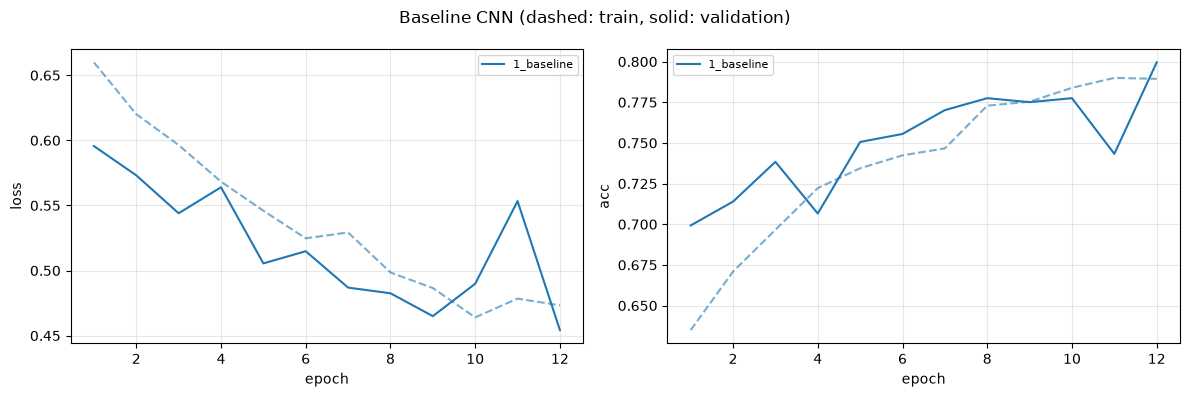

In [ ]:
train_model("1_baseline", make_cnn(batch_norm=False))
plot_curves(["1_baseline"], "Baseline CNN")

## 3. Batch normalisation
Keep the architecture and optimiser unchanged; add batch normalisation.

2_batchnorm
 1/12  train loss 0.572 acc 0.706 | val loss 0.666 acc 0.599
 2/12  train loss 0.492 acc 0.773 | val loss 0.592 acc 0.670
 3/12  train loss 0.444 acc 0.799 | val loss 0.499 acc 0.790
 4/12  train loss 0.451 acc 0.797 | val loss 0.470 acc 0.790
 5/12  train loss 0.432 acc 0.792 | val loss 0.785 acc 0.714
 6/12  train loss 0.432 acc 0.810 | val loss 0.428 acc 0.817
 7/12  train loss 0.402 acc 0.823 | val loss 0.436 acc 0.802
 8/12  train loss 0.415 acc 0.813 | val loss 0.471 acc 0.800
 9/12  train loss 0.398 acc 0.828 | val loss 0.418 acc 0.822
10/12  train loss 0.383 acc 0.830 | val loss 0.516 acc 0.804
11/12  train loss 0.378 acc 0.838 | val loss 0.441 acc 0.795
12/12  train loss 0.344 acc 0.857 | val loss 0.456 acc 0.802
Best validation accuracy: 0.8215


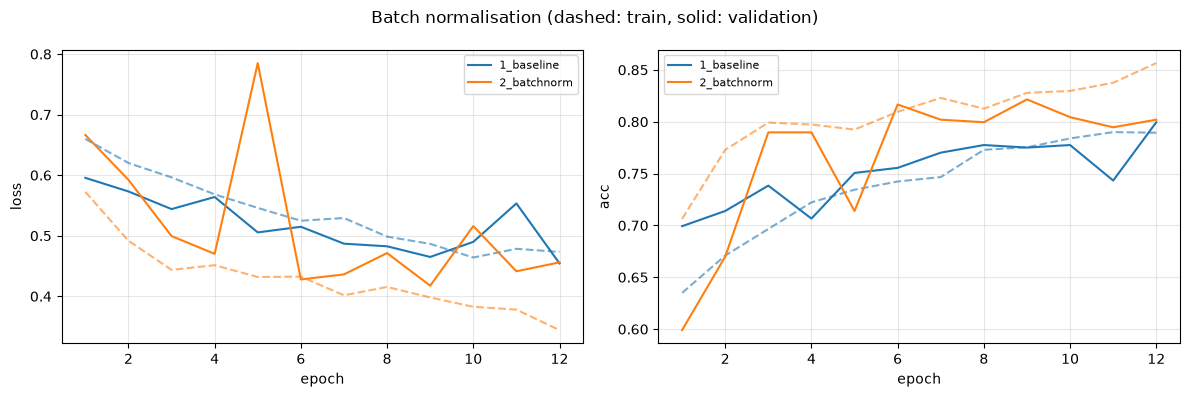

In [7]:
train_model("2_batchnorm", make_cnn())
plot_curves(["1_baseline", "2_batchnorm"], "Batch normalisation")

## 4. Optimisers
Compare SGD, momentum and Adam on the same CNN. Adam reuses the batch-normalisation run.
SGD and momentum use a learning rate of 0.01; Adam uses 0.001.

3_sgd
 1/12  train loss 0.630 acc 0.647 | val loss 0.645 acc 0.606
 2/12  train loss 0.592 acc 0.693 | val loss 0.603 acc 0.655
 3/12  train loss 0.560 acc 0.722 | val loss 0.606 acc 0.665
 4/12  train loss 0.541 acc 0.736 | val loss 0.518 acc 0.736
 5/12  train loss 0.521 acc 0.752 | val loss 0.509 acc 0.773
 6/12  train loss 0.515 acc 0.756 | val loss 0.562 acc 0.726
 7/12  train loss 0.496 acc 0.771 | val loss 0.620 acc 0.682
 8/12  train loss 0.487 acc 0.789 | val loss 0.469 acc 0.773
 9/12  train loss 0.483 acc 0.773 | val loss 0.575 acc 0.711
10/12  train loss 0.477 acc 0.781 | val loss 0.476 acc 0.778
11/12  train loss 0.467 acc 0.793 | val loss 0.543 acc 0.721
12/12  train loss 0.455 acc 0.797 | val loss 0.608 acc 0.702
Best validation accuracy: 0.7775
3_momentum
 1/12  train loss 0.605 acc 0.686 | val loss 0.618 acc 0.641
 2/12  train loss 0.534 acc 0.741 | val loss 0.554 acc 0.707
 3/12  train loss 0.493 acc 0.771 | val loss 0.518 acc 0.770
 4/12  train loss 0.524 acc 0.755 |

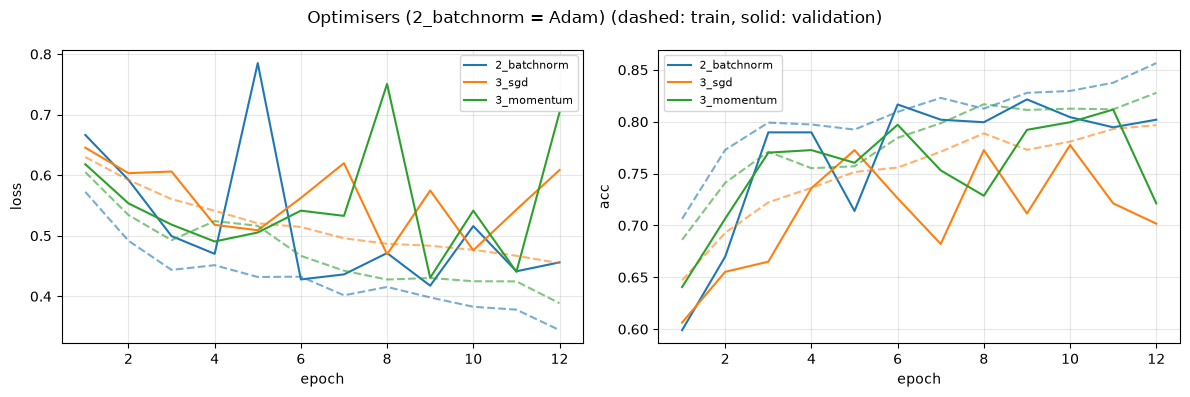

In [8]:
for optimizer in ["sgd", "momentum"]:
    train_model(f"3_{optimizer}", make_cnn(), optimizer=optimizer, lr=1e-2)
plot_curves(["2_batchnorm", "3_sgd", "3_momentum"], "Optimisers (2_batchnorm = Adam)")

## 5. Data augmentation
Compare the same model with and without training augmentation, using identical split indices.

4_augmented
 1/12  train loss 0.579 acc 0.708 | val loss 0.585 acc 0.711
 2/12  train loss 0.507 acc 0.757 | val loss 0.653 acc 0.623
 3/12  train loss 0.487 acc 0.769 | val loss 0.523 acc 0.756
 4/12  train loss 0.483 acc 0.772 | val loss 0.435 acc 0.792
 5/12  train loss 0.469 acc 0.783 | val loss 0.835 acc 0.709
 6/12  train loss 0.480 acc 0.777 | val loss 0.415 acc 0.812
 7/12  train loss 0.444 acc 0.805 | val loss 0.468 acc 0.807
 8/12  train loss 0.456 acc 0.786 | val loss 0.400 acc 0.831
 9/12  train loss 0.432 acc 0.792 | val loss 0.492 acc 0.765
10/12  train loss 0.436 acc 0.798 | val loss 0.461 acc 0.802
11/12  train loss 0.427 acc 0.810 | val loss 0.470 acc 0.800
12/12  train loss 0.409 acc 0.824 | val loss 0.447 acc 0.795
Best validation accuracy: 0.8313


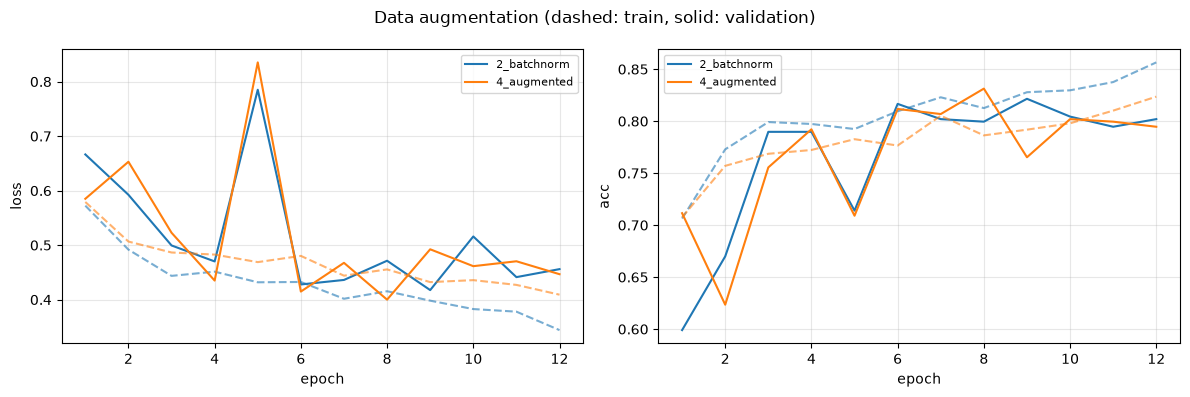

In [9]:
train_model("4_augmented", make_cnn(), loader=aug_train_loader)
plot_curves(["2_batchnorm", "4_augmented"], "Data augmentation")

## 6. Architecture
Try twice as many channels, then an extra block with dropout. The second variant changes
both depth and dropout, so it measures their combined effect.

5_wider
 1/12  train loss 0.583 acc 0.705 | val loss 0.660 acc 0.619
 2/12  train loss 0.518 acc 0.755 | val loss 0.571 acc 0.697
 3/12  train loss 0.496 acc 0.763 | val loss 0.482 acc 0.778
 4/12  train loss 0.495 acc 0.754 | val loss 0.550 acc 0.743
 5/12  train loss 0.478 acc 0.770 | val loss 1.123 acc 0.621
 6/12  train loss 0.479 acc 0.785 | val loss 0.624 acc 0.685
 7/12  train loss 0.445 acc 0.791 | val loss 0.559 acc 0.756
 8/12  train loss 0.464 acc 0.786 | val loss 0.432 acc 0.795
 9/12  train loss 0.437 acc 0.800 | val loss 0.572 acc 0.704
10/12  train loss 0.428 acc 0.810 | val loss 0.434 acc 0.795
11/12  train loss 0.422 acc 0.818 | val loss 0.635 acc 0.724
12/12  train loss 0.404 acc 0.828 | val loss 0.421 acc 0.819
Best validation accuracy: 0.8191
5_deeper_dropout
 1/12  train loss 0.609 acc 0.689 | val loss 0.627 acc 0.621
 2/12  train loss 0.532 acc 0.748 | val loss 0.484 acc 0.768
 3/12  train loss 0.477 acc 0.787 | val loss 0.458 acc 0.797
 4/12  train loss 0.470 acc

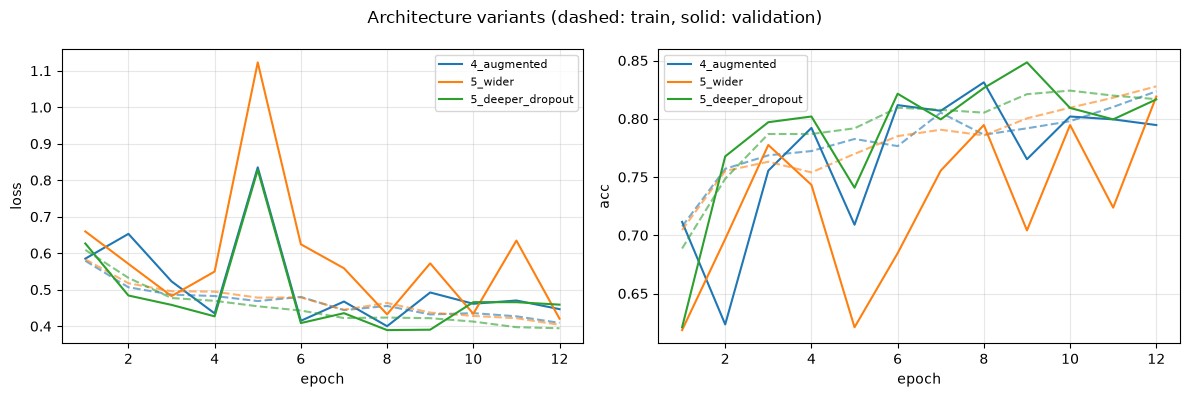

In [10]:
for name, settings in {
    "5_wider": {"width": 32},
    "5_deeper_dropout": {"n_blocks": 5, "dropout": 0.3},
}.items():
    train_model(name, make_cnn(**settings), loader=aug_train_loader)
plot_curves(["4_augmented", "5_wider", "5_deeper_dropout"], "Architecture variants")

## 7. Transfer learning
Compare a pretrained ResNet18 with a frozen backbone, a fully fine-tuned ResNet18,
and the same architecture trained from scratch. All three use augmented training data.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\chris/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.10MB/s]


6_resnet_frozen
 1/6  train loss 0.386 acc 0.822 | val loss 0.256 acc 0.890
 2/6  train loss 0.235 acc 0.903 | val loss 0.219 acc 0.912
 3/6  train loss 0.205 acc 0.919 | val loss 0.209 acc 0.910
 4/6  train loss 0.205 acc 0.916 | val loss 0.213 acc 0.914
 5/6  train loss 0.198 acc 0.921 | val loss 0.207 acc 0.907
 6/6  train loss 0.188 acc 0.921 | val loss 0.210 acc 0.905
Best validation accuracy: 0.9144
6_resnet_finetune
 1/6  train loss 0.312 acc 0.853 | val loss 0.178 acc 0.929
 2/6  train loss 0.127 acc 0.952 | val loss 0.155 acc 0.939
 3/6  train loss 0.068 acc 0.979 | val loss 0.153 acc 0.929
 4/6  train loss 0.039 acc 0.993 | val loss 0.135 acc 0.946
 5/6  train loss 0.028 acc 0.990 | val loss 0.155 acc 0.929
 6/6  train loss 0.028 acc 0.987 | val loss 0.212 acc 0.927
Best validation accuracy: 0.9462
6_resnet_scratch
 1/6  train loss 0.623 acc 0.658 | val loss 0.580 acc 0.704
 2/6  train loss 0.503 acc 0.764 | val loss 0.500 acc 0.748
 3/6  train loss 0.501 acc 0.755 | val loss

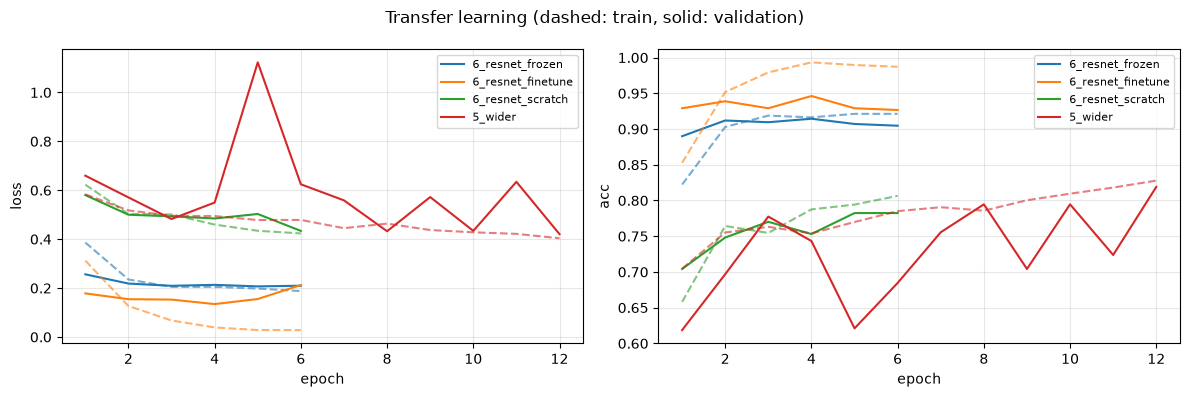

In [11]:
def make_resnet18(pretrained=True, freeze=False):
    torch.manual_seed(SEED)
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    if freeze:
        model.requires_grad_(False)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


for name, pretrained, freeze, lr in [
    ("6_resnet_frozen", True, True, 1e-3),
    ("6_resnet_finetune", True, False, 1e-4),
    ("6_resnet_scratch", False, False, 1e-4),
]:
    train_model(name, make_resnet18(pretrained, freeze), loader=aug_train_loader,
                epochs=RESNET_EPOCHS, lr=lr)
plot_curves(["6_resnet_frozen", "6_resnet_finetune", "6_resnet_scratch", "5_wider"],
            "Transfer learning")

## 8. Results
Build the comparison table from the runs in memory. Saving the notebook keeps the
displayed table and curves available after a kernel restart.

In [12]:
results = pd.DataFrame([
    {"run": name, "best val acc": run["best_val_acc"],
     "final train acc": run["train_acc"][-1], "optimizer": run["optimizer"],
     "lr": run["lr"], "params": run["params"], "epochs": run["epochs"], "minutes": run["minutes"]}
    for name, run in runs.items()
]).sort_values("best val acc", ascending=False)
results.round(4)

,run,best val acc,final train acc,optimizer,lr,params,epochs,minutes
8,6_resnet_finetune,0.9462,0.9872,adam,0.0001,11177538,6,3.2555
7,6_resnet_frozen,0.9144,0.9212,adam,0.0010,1026,6,1.6579
6,5_deeper_dropout,0.8484,0.8168,adam,0.0010,394114,12,2.7929
4,4_augmented,0.8313,0.8236,adam,0.0010,98178,12,2.8606
1,2_batchnorm,0.8215,0.8565,adam,0.0010,98178,12,2.4332
5,5_wider,0.8191,0.8278,adam,0.0010,389890,12,4.7510
3,3_momentum,0.8117,0.8278,momentum,0.0100,98178,12,2.5499
0,1_baseline,0.7995,0.7894,adam,0.0010,97698,12,2.2277
9,6_resnet_scratch,0.7824,0.8065,adam,0.0001,11177538,6,3.3352
2,3_sgd,0.7775,0.7967,sgd,0.0100,98178,12,2.4753


## 9. Final test evaluation
Automatically select the highest validation accuracy and evaluate its restored best weights.
Reuse these predictions for the confusion matrix and error analysis.

In [13]:
BEST_RUN = max(runs, key=lambda name: runs[name]["best_val_acc"])
best_model = runs[BEST_RUN]["model"]
test = evaluate(best_model, test_loader)
correct = (test["preds"] == test["labels"]).sum().item()
print(f"run: {BEST_RUN}")
print(f"TEST accuracy: {test['acc']:.4f} ({correct} / {len(test['labels'])} correct)")
print(f"test loss: {test['loss']:.4f}")

run: 6_resnet_finetune
TEST accuracy: 0.9296 (1731 / 1862 correct)
test loss: 0.2242


In [14]:
pd.crosstab(
    pd.Series([CLASS_NAMES[i] for i in test["labels"]], name="true"),
    pd.Series([CLASS_NAMES[i] for i in test["preds"]], name="predicted"),
).reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)

predicted,hotdog,nothotdog
true,,
hotdog,827,68
nothotdog,63,904


## 10. Misclassified images
Inspect the most confident mistakes. Look for ambiguous food, small hotdogs or misleading backgrounds.

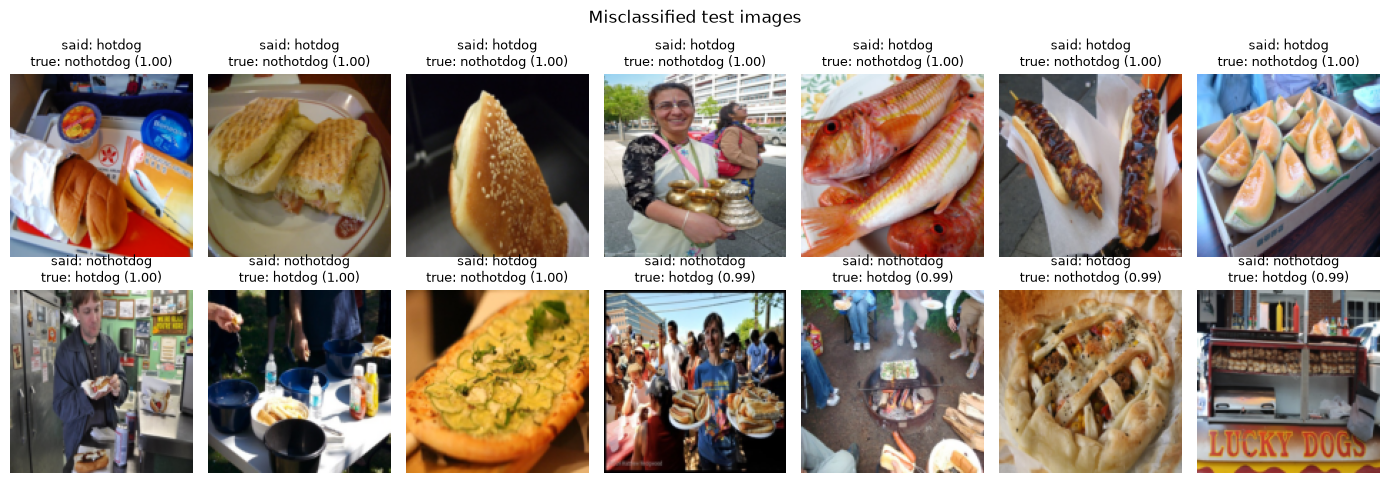

In [15]:
wrong = (test["preds"] != test["labels"]).nonzero().flatten()
confidence = test["probs"][wrong].max(dim=1).values
wrong = wrong[confidence.argsort(descending=True)][:14].tolist()
if wrong:
    images = torch.stack([test_data[i][0] for i in wrong])
    titles = [f"said: {CLASS_NAMES[test['preds'][i]]}\ntrue: {CLASS_NAMES[test['labels'][i]]}"
              f" ({test['probs'][i].max():.2f})" for i in wrong]
    show_images(images, titles, "Misclassified test images")
else:
    print("No misclassified test images.")

## 11. Saliency and SmoothGrad
Saliency takes the absolute gradient of a predicted class score with respect to the
input, then the maximum over RGB channels. These maps show local sensitivity to pixels.

SmoothGrad averages maps from noisy copies of an image, keeping the explained class fixed.
If $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$, then
$x + \varepsilon \sim \mathcal{N}(x, \sigma^2 I)$: adding the fixed image shifts
the mean but leaves the covariance unchanged. Vary the noise level below to compare maps.

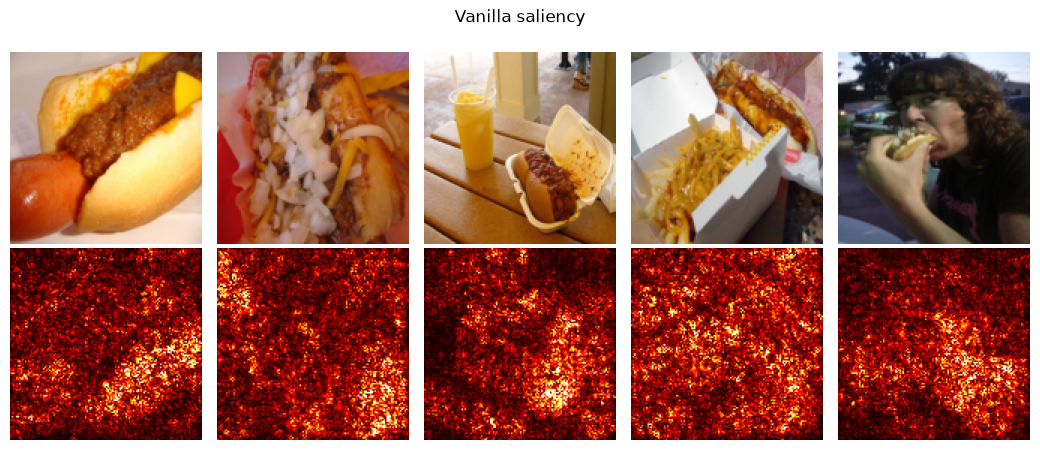

In [16]:
def saliency(model, images, labels):
    model.to(device).eval()
    images = images.detach().clone().to(device).requires_grad_(True)
    score = model(images).gather(1, labels.to(device)[:, None]).sum()
    gradient, = torch.autograd.grad(score, images)
    return gradient.abs().amax(dim=1).cpu()


def show_saliency(model, images, noise_level=0.0, n_samples=50):
    model.to(device).eval()
    with torch.no_grad():
        labels = model(images.to(device)).argmax(dim=1)
    if noise_level:
        sigma = noise_level * (images.max() - images.min())
        maps = torch.zeros(len(images), *images.shape[-2:])
        for _ in range(n_samples):
            maps += saliency(model, images + sigma * torch.randn_like(images), labels)
        maps /= n_samples
    else:
        maps = saliency(model, images, labels)
    fig, axes = plt.subplots(2, len(images), figsize=(2.1 * len(images), 4.6), squeeze=False)
    for i in range(len(images)):
        axes[0, i].imshow(denormalize(images[i]))
        axes[1, i].imshow(maps[i], cmap="hot", vmax=maps[i].quantile(0.99).item())
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(f"SmoothGrad (noise={noise_level}, samples={n_samples})" if noise_level else "Vanilla saliency")
    fig.tight_layout()
    plt.show()


hotdog_label = test_data.class_to_idx["hotdog"]
example_idx = [i for i, label in enumerate(test_data.targets) if label == hotdog_label][:5]
examples = torch.stack([test_data[i][0] for i in example_idx])
show_saliency(best_model, examples)

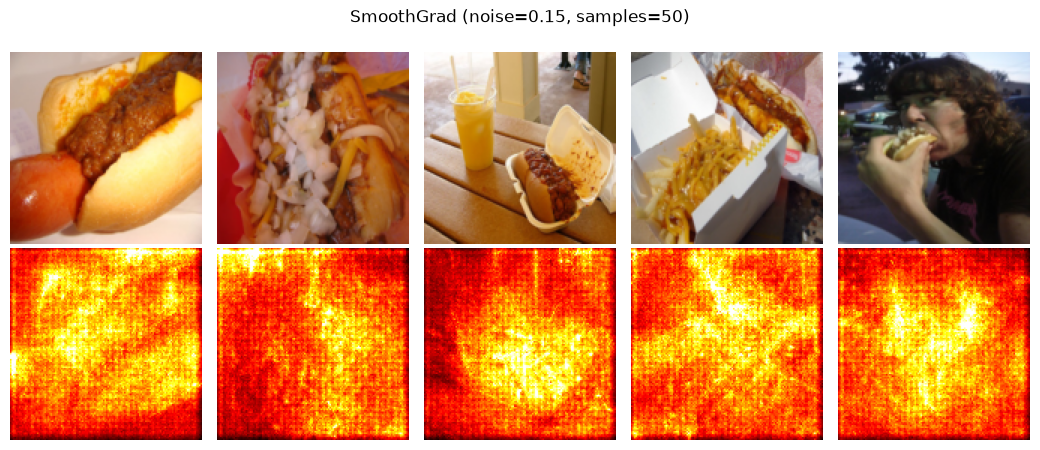

In [17]:
show_saliency(best_model, examples, noise_level=0.15)

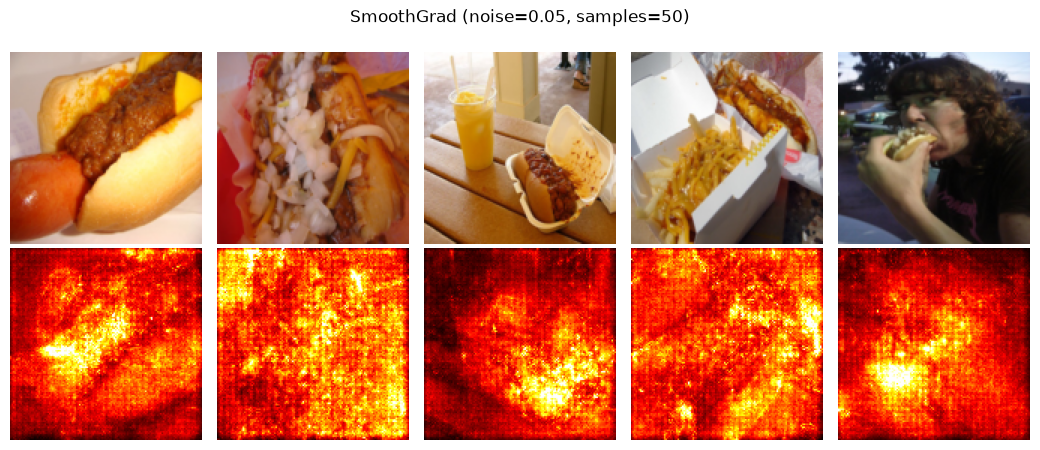

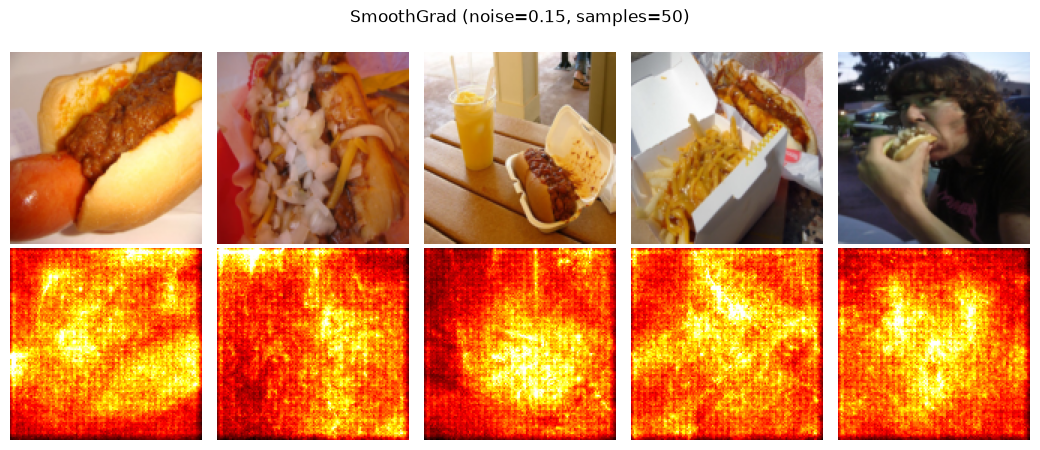

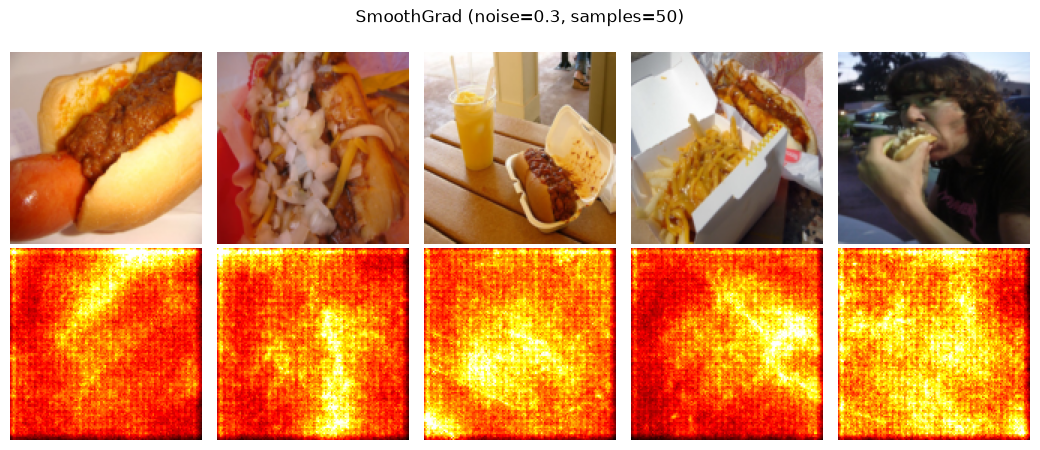

In [18]:
for noise in [0.05, 0.15, 0.30]:
    show_saliency(best_model, examples, noise_level=noise)

Discuss whether the maps highlight the hotdog, the background or another object, and how
the noise level changes the result. Consider these maps alongside the misclassified images.

## 12. Report notes
Explain the architecture choices, optimiser comparison, batch normalisation, augmentation,
transfer learning, final test accuracy, mistakes and saliency results using the outputs above.
Add an accurate paragraph describing your use of generative AI, including this notebook refactor.